# **模块**: 基于PCA的多元统计过程监控
## **课程**: PCA工业案例研究
### *主题*:  故障检测

In [1]:
# 导入所需包
import numpy as np, pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
# 中文显示设置
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False


np.set_printoptions(precision=3, suppress=True)

In [2]:
# ==================================================================================
#                        读取并探索数据集
# ==================================================================================

In [6]:
#%% fetch data
data = pd.read_excel('proc1a.xlsx',skiprows=1,usecols='C:AI')

print("\n 前几行数据：")
print(data.head())


 前几行数据：
   x1in  x2in  x3in  x4in  x5in  x6in  x7in    y1    y2    y3  ...  xgnx  \
0  0.47 -1.66 -0.19  1.94  0.07 -4.54 -0.09 -1.13  0.62  0.24  ... -0.13   
1  0.05 -0.83  0.04  0.75  0.25 -0.02 -0.60 -0.89  0.68  0.14  ... -0.17   
2 -0.58 -0.21 -0.08  0.89  0.34  0.12 -0.86 -0.81  0.77  0.12  ...  0.07   
3 -0.90  0.11  0.16  1.43  0.45  0.13 -0.41 -0.70  0.69  0.21  ...  0.17   
4 -0.78 -0.33 -0.34  1.51  0.50 -0.01 -0.31 -0.38  0.91  0.07  ...  0.14   

   xhnx  xinx  xjnx  xknx  xlnx  xmen  xnen  xoen  xpen  
0 -0.12  0.24  0.22 -0.01  0.27 -0.21  0.38  0.09 -0.11  
1 -0.11  0.22  0.05 -0.08  0.18 -0.33  0.34 -0.04 -0.33  
2 -0.17  0.20 -0.02 -0.13  0.31 -0.41  0.22  0.04 -0.01  
3 -0.01  0.29  0.07  0.01  0.30 -0.49  0.30 -0.22  0.00  
4 -0.05  0.26  0.06 -0.04  0.33 -0.58  0.23 -0.27 -0.28  

[5 rows x 33 columns]


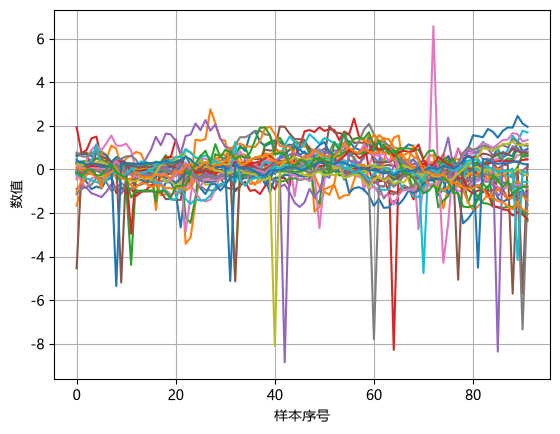

In [7]:
#%% visualize complete data
plt.figure()
plt.plot(data)
plt.ylabel('数值'), plt.xlabel('样本序号')
plt.grid()

In [8]:
# ==================================================================================
#                        拟合PCA模型 
# ==================================================================================

In [9]:
# 划分训练数据
data_train = data.iloc[0:69,]
           
# 缩放数据
scaler = StandardScaler()
data_train_normal = scaler.fit_transform(data_train)
           
# 拟合PCA（默认保留所有主成分）
pca = PCA()
scores_train = pca.fit_transform(data_train_normal)

print('scores_train 矩阵形状：', scores_train.shape)

scores_train 矩阵形状： (69, 33)


##### 我们尚未完成降维。PCA只是在scores_train中提供了不相关的数据集。为验证这一点，可计算score_train各列之间相关系数的热力图。 

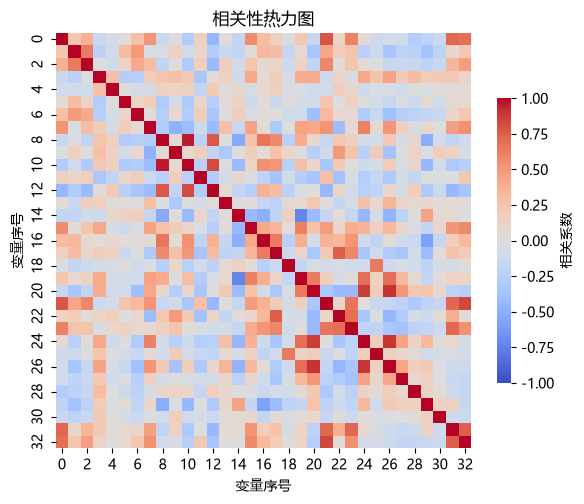

In [10]:
# 原始缩放变量间相关系数热力图
import seaborn as sns

# 计算相关系数矩阵
correlation_matrix_originalVariables = np.corrcoef(data_train_normal.T)

# 创建热力图
plt.figure(figsize=(6, 6))
sns.heatmap(correlation_matrix_originalVariables, 
            cmap='coolwarm',  # Color scheme (red for positive, blue for negative correlations)
            vmin=-1,  # Minimum correlation value
            vmax=1,   # Maximum correlation value
            center=0, # Center the colormap at 0
            square=True, # Make the plot square-shaped
            cbar_kws={
                'shrink': 0.5,  # height
                'label': '相关系数',  # add label
            }) # Format correlation values to 2 decimal places

plt.xlabel('变量序号'), plt.ylabel('变量序号')
plt.title('相关性热力图')
plt.tight_layout()
plt.show()

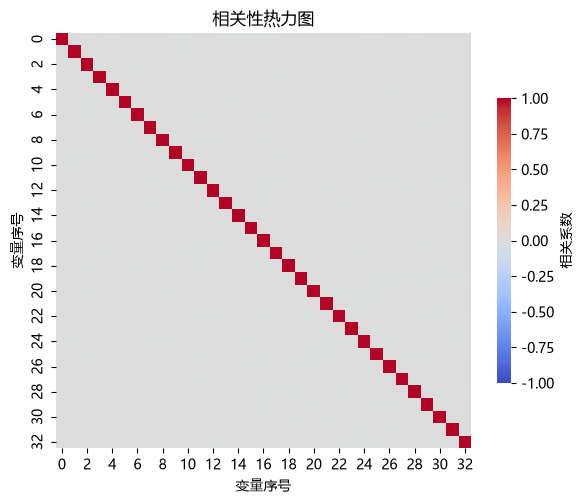

In [11]:
# 变换后变量间相关系数热力图
correlation_matrix_Scores = np.corrcoef(scores_train.T)

# 创建热力图
plt.figure(figsize=(6, 6))
sns.heatmap(correlation_matrix_Scores, 
            cmap='coolwarm',  # Color scheme (red for positive, blue for negative correlations)
            vmin=-1,  # Minimum correlation value
            vmax=1,   # Maximum correlation value
            center=0, # Center the colormap at 0
            square=True, # Make the plot square-shaped
            cbar_kws={
                'shrink': 0.5,  # height
                'label': '相关系数',  # add label
            }) # Format correlation values to 2 decimal places

plt.xlabel('变量序号'), plt.ylabel('变量序号')
plt.title('相关性热力图')
plt.tight_layout()
plt.show()

##### 现在来看各主成分捕获的方差

In [12]:
# 获取各主成分得分的特征值或方差
variances_captured = pca.explained_variance_
print('主成分得分方差：', variances_captured)

主成分得分方差： [6.423 5.529 5.218 2.576 1.949 1.655 1.424 1.275 1.03  1.005 0.865 0.839
 0.667 0.618 0.568 0.318 0.259 0.235 0.207 0.172 0.16  0.106 0.087 0.067
 0.051 0.044 0.038 0.032 0.023 0.021 0.015 0.008 0.   ]


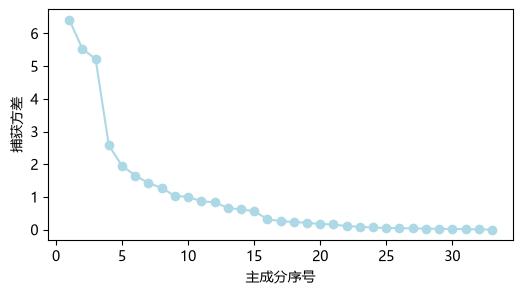

In [13]:
# 可视化方差 
plt.figure(figsize=(6,3))
plt.plot(range(1, len(variances_captured) + 1), variances_captured, color='lightblue', marker='o')
plt.xlabel('主成分序号'), plt.ylabel('捕获方差')
plt.show()

In [14]:
# ==================================================================================
#                   通过CPV图确定保留的主成分数量
# ==================================================================================

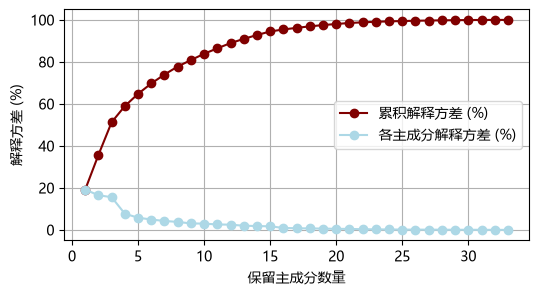

In [15]:
explained_variance = 100*pca.explained_variance_ratio_ # in percentage
cum_explained_variance = np.cumsum(explained_variance) # cumulative % variance explained

plt.figure(figsize=(6,3))
plt.plot(range(1, len(variances_captured) + 1), cum_explained_variance, color='maroon', marker='o', label = '累积解释方差 (%)')
plt.plot(range(1, len(variances_captured) + 1), explained_variance, color='lightblue', marker='o', label = '各主成分解释方差 (%)')
plt.ylabel('解释方差 (%)')
plt.xlabel('保留主成分数量')
plt.legend()
plt.grid()
plt.show()

In [16]:
# 确定保留的主成分数量
n_comp = np.argmax(cum_explained_variance >= 90) + 1
print('累积解释至少 90% 方差的主成分数：', n_comp)

累积解释至少 90% 方差的主成分数： 13


In [17]:
# ==================================================================================
#                   执行降维
# ==================================================================================

In [18]:
# 计算主成分空间中的降维数据
scores_train_reduced = scores_train[:,0:n_comp]
print('得分矩阵形状：', scores_train_reduced.shape)

得分矩阵形状： (69, 13)


In [19]:
# ==================================================================================
#              用减少的主成分数量重新拟合PCA
# ==================================================================================

In [20]:
# 拟合PCA（仅保留n_comp个主成分）
pca = PCA(n_components=n_comp)  # retain only n_comp PCs
scores_train_reduced = pca.fit_transform(data_train_normal)

print('得分矩阵形状：', scores_train_reduced.shape)

得分矩阵形状： (69, 13)


##### 使用降维后的得分矩阵重构数据，并直观确认仅丢失了少量信息。

In [21]:
# ==================================================================================
#                               重构
# ==================================================================================

In [22]:
data_train_normal_reconstruct = pca.inverse_transform(scores_train_reduced)

print('重构 X（归一化）矩阵形状：', data_train_normal_reconstruct.shape)

重构 X（归一化）矩阵形状： (69, 33)


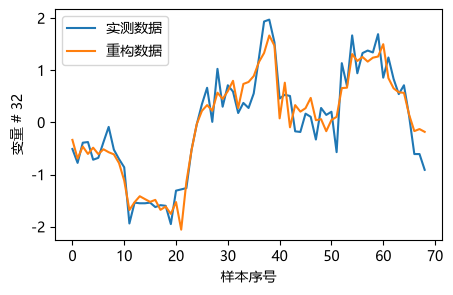

In [23]:
# 绘制原始与重构变量对比图
var = 32
plt.figure(figsize=(5,3))
plt.plot(data_train_normal[:,var],label = '实测数据')
plt.plot(data_train_normal_reconstruct[:,var],label = '重构数据')
plt.ylabel('变量 # '+ str(var))
plt.xlabel('样本序号')
plt.legend()
plt.show()

In [24]:
# ==================================================================================
#                计算训练样本的T²与Q统计量
# ==================================================================================

In [25]:
# 计算训练数据的T2统计量
lambda_k = np.diag(pca.explained_variance_) # eigenvalue = explained variance
lambda_k_inv = np.linalg.inv(lambda_k)

T2_train = np.zeros((data_train_normal.shape[0],))

for i in range(data_train_normal.shape[0]):
    T2_train[i] = np.dot(np.dot(scores_train_reduced[i,:], lambda_k_inv), scores_train_reduced[i,:].T)

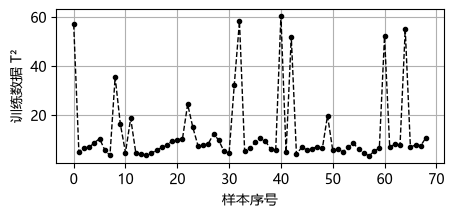

In [26]:
# 绘制T2_train  
plt.figure(figsize=(5,2))
plt.plot(T2_train, color='black', linestyle='--', linewidth=1, marker='o', markersize=3)
plt.xlabel('样本序号'), plt.ylabel('训练数据 T²')
plt.grid()
plt.show()

In [27]:
# 计算训练数据的Q统计量
error_train = data_train_normal - data_train_normal_reconstruct
Q_train = np.sum(error_train*error_train, axis = 1)

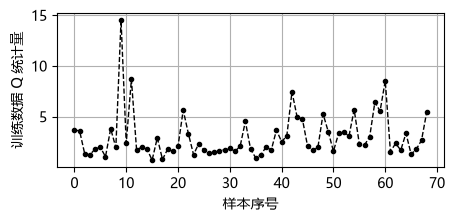

In [28]:
# 绘制Q_train  
plt.figure(figsize=(5,2))
plt.plot(Q_train, color='black', linestyle='--', linewidth=1, marker='o', markersize=3)
plt.xlabel('样本序号'), plt.ylabel('训练数据 Q 统计量')
plt.grid()
plt.show()

In [29]:
# ==================================================================================
#          计算T²与Q指标的控制限 
# ==================================================================================

In [30]:
# T2_train控制限
T2_CL = np.percentile(T2_train, 99)

print('T² 控制限：', T2_CL)

T² 控制限： 58.96752157797488


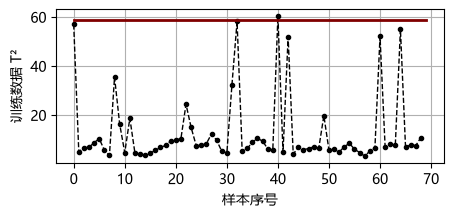

In [31]:
# 绘制带控制限的T2_train
plt.figure(figsize=(5,2))
plt.plot(T2_train, color='black', linestyle='--', linewidth=1, marker='o', markersize=3)
plt.plot([0,len(T2_train)],[T2_CL,T2_CL], color='maroon', linewidth=2)
plt.xlabel('样本序号'), plt.ylabel('训练数据 T²')
plt.grid()
plt.show()

In [32]:
# Q_train控制限
Q_CL = np.percentile(Q_train, 99)
print('Q 控制限：', Q_CL)

Q 控制限： 10.54088875295396


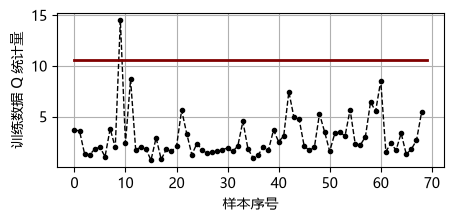

In [33]:
# 绘制带控制限的Q_train
plt.figure(figsize=(5,2))
plt.plot(Q_train, color='black', linestyle='--', linewidth=1, marker='o', markersize=3)
plt.plot([0,len(Q_train)],[Q_CL,Q_CL], color='maroon', linewidth=2)
plt.xlabel('样本序号'), plt.ylabel('训练数据 Q 统计量')
plt.grid()
plt.show()

In [34]:
##%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
##              对测试数据执行故障检测
## %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

In [35]:
# 获取测试数据并归一化
data_test = data.iloc[69:,]
data_test_normal = scaler.transform(data_test) # using scaling parameters from training data

# 计算得分
scores_test_reduced = pca.transform(data_test_normal)

# 重构
data_test_normal_reconstruct = pca.inverse_transform(scores_test_reduced)

In [36]:
# 计算T2_test
T2_test = np.zeros((data_test_normal.shape[0],))

for i in range(data_test_normal.shape[0]):
    T2_test[i] = np.dot(np.dot(scores_test_reduced[i,:], lambda_k_inv), scores_test_reduced[i,:].T)

# 计算Q_test
error_test = data_test_normal_reconstruct - data_test_normal
Q_test = np.sum(error_test*error_test, axis = 1)

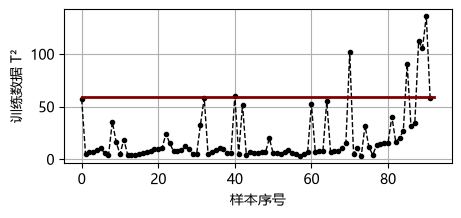

In [37]:
# 绘制完整数据集的T²控制图
T2_combined = np.concatenate([T2_train,T2_test])

plt.figure(figsize=(5,2))
plt.plot(T2_combined, color='black', linestyle='--', linewidth=1, marker='o', markersize=3)
plt.plot([0,len(T2_combined)],[T2_CL,T2_CL], color='maroon', linewidth=2)
plt.xlabel('样本序号'), plt.ylabel('训练数据 T²')
plt.grid()
plt.show()

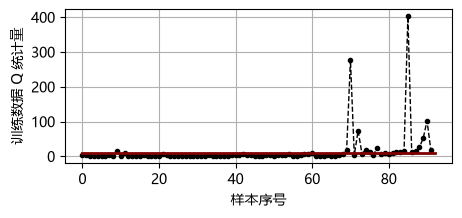

In [38]:
# 绘制完整数据集的SPE控制图
Q_combined = np.concatenate([Q_train,Q_test])

plt.figure(figsize=(5,2))
plt.plot(Q_combined, color='black', linestyle='--', linewidth=1, marker='o', markersize=3)
plt.plot([0,len(Q_combined)],[Q_CL,Q_CL], color='maroon', linewidth=2)
plt.xlabel('样本序号'), plt.ylabel('训练数据 Q 统计量')
plt.grid()
plt.show()

In [39]:
##%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
##                  使用贡献图进行故障隔离
## %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

In [40]:
sample = 85 - 69

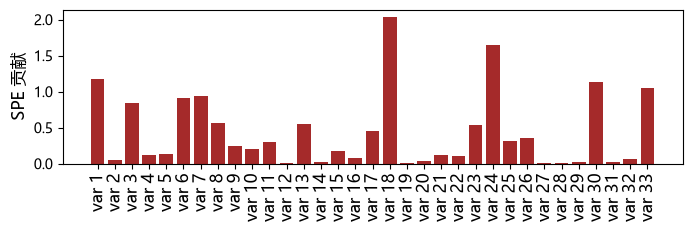

In [41]:
# SPE贡献图
error_test_sample = error_test[sample-1,]
SPE_contri = error_test_sample*error_test_sample # vector of contributions

plt.figure(figsize=[8,2])
plt.bar(['var ' + str((i+1)) for i in range(len(SPE_contri))], SPE_contri, color='brown')
plt.xticks(rotation = 90, fontsize=12)
plt.ylabel('SPE 贡献', fontsize=12)
plt.show()

D:\MyWork\ML_Process\Statistical-Process\.venv\Lib\site-packages\matplotlib\cbook.py:1810: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
D:\MyWork\ML_Process\Statistical-Process\.venv\Lib\site-packages\matplotlib\transforms.py:844: ComplexWarning: Casting complex values to real discards the imaginary part
  bbox = Bbox(np.asarray(args, dtype=float).reshape((2, 2)))


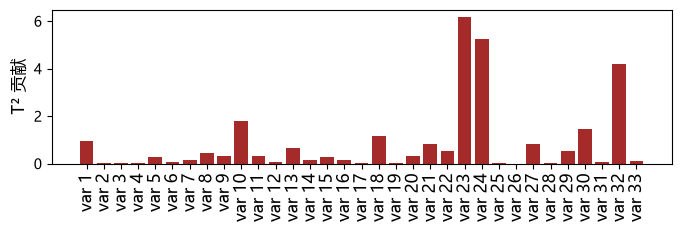

In [42]:
# T2贡献图
import scipy

data_point = np.transpose(data_test_normal[sample-1,])
P_matrix = pca.components_.T # projection matrix

D = np.dot(np.dot(P_matrix, lambda_k_inv), P_matrix.T)
T2_contri = np.dot(scipy.linalg.sqrtm(D), data_point)**2 # vector of contributions

plt.figure(figsize=[8,2])
plt.bar(['var ' + str((i+1)) for i in range(len(T2_contri))], T2_contri, color='brown')
plt.xticks(rotation = 90, fontsize=12)
plt.ylabel('T² 贡献', fontsize=12)
plt.show()

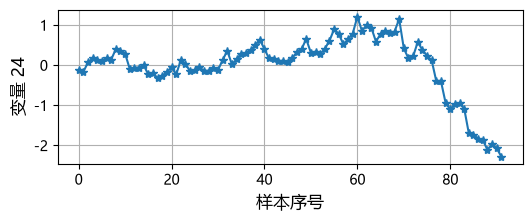

In [43]:
# 变量图
plt.figure(figsize=[6,2])
plt.plot(data.iloc[:,23], '-*')
plt.xlabel('样本序号', fontsize=12)
plt.ylabel('变量 24', fontsize=12)
plt.grid()
plt.show()